# Query By Committee Polymer Sampling
Select the samples with the most disagreement amongst models and then diversity pick from the most disagreed samples.
1. Measure disagreement with KL divergence from mean probability
2. select only from Q4 and remove outliers via 1.5 IQR Method
2. 

In [1]:
from uncertainty_sampling import get_inference_results, show_exploratory_analysis, select_most_uncertain, get_target_polymers_with_features
from diversity_sampling import get_diversity_samples
import pandas as pd
import numpy as np
from pathlib import Path

# QBC

## Retrieve Multimodel Inference Results

In [ ]:
#### 
# Query by commitee
inference_results_dir = Path("../inference_results/")

######
# Process inference results
dfs = []
for i, inference_dir in enumerate(inference_results_dir.iterdir()):
    if inference_dir.is_dir():
        print(f"processing {inference_dir}")
        df = get_inference_results(inference_dir)
        # Add analysis columns
        df["binary_prediction"] = df["pred"].map(lambda x: 1 if x > 0.5 else 0)
        df["entropy"] = df["pred"].map(
            lambda x: -1
            * (x * np.log2(x) + (1 - x) * np.log2(1 - x) if x > 0 and x < 1 else 0)
        )

        # Show exploratory analysis
        show_exploratory_analysis(df, save_dir="analysis", model_name=inference_dir.name)
        
        df = df.set_index('ID')
        display(df.head())

        df.rename(columns={k: f"{k}_{inference_dir.name}" for k in df.columns}, inplace=True)
        dfs.append(df)
display(df.head())

In [3]:
df_preds_all = pd.concat(dfs, axis=1)
df_preds_all

,pred_MPNN_40,binary_prediction_MPNN_40,entropy_MPNN_40,pred_MPNN_85,binary_prediction_MPNN_85,entropy_MPNN_85,pred_MPNN_16,binary_prediction_MPNN_16,entropy_MPNN_16
ID,,,,,,,,,
3530266_1,0.500000,1,1.0,0.622063,1,0.956572,0.000758,0,0.008949
6563722_1,0.499999,0,1.0,0.948139,1,0.294252,0.302227,0,0.883996
3726862_1,0.500002,1,1.0,0.582454,1,0.980293,0.008456,0,0.070371
2333238_1,0.499998,0,1.0,0.177739,0,0.675106,1.000000,1,0.000000
3621884_1,0.499998,0,1.0,0.695112,1,0.887184,0.004218,0,0.039346
...,...,...,...,...,...,...,...,...,...
6852128_1,1.000000,1,0.0,0.999567,1,0.005460,1.000000,1,0.000000
5710205_1,1.000000,1,0.0,0.998289,1,0.018196,1.000000,1,0.000000
1321711_1,1.000000,1,0.0,0.998482,1,0.016400,0.964264,1,0.222390


## Calculate Mean KL Divergence for All Models

In [4]:
import swifter
import numpy as np

# Define tolerance
tolerance = 1e-6

# Selecting the prediction columns
prediction_columns = [c for c in df_preds_all.columns if "pred_" in c]

# Calculating the mean probabilities for positive and negative predictions
df_preds_all['mean_pos_prob'] = df_preds_all[prediction_columns].mean(axis=1).replace(0, tolerance).replace(1, 1-tolerance)
df_preds_all['mean_neg_prob'] = 1 - df_preds_all[prediction_columns].mean(axis=1).replace(0, tolerance).replace(1, 1-tolerance)

def get_kl(row, col):
    prob = row[col]
    mean_pos_prob = row['mean_pos_prob']
    mean_neg_prob = row['mean_neg_prob']

    kl = prob * np.log2(prob / (mean_pos_prob)) + \
        (1 - prob) * np.log2((1 - prob) / (mean_neg_prob))

    return kl

result = pd.DataFrame()
for col in prediction_columns:
    df_preds_all[col] = df_preds_all[col].replace(0, tolerance).replace(1, 1-tolerance)
    result[f"{col}_kldiv"] = df_preds_all.swifter.apply(lambda x: get_kl(x, col), axis=1)

df_preds_all['KLdiv'] = result[[f"{c}_kldiv" for c in prediction_columns]].mean(axis=1)

display(df_preds_all.head())
display(df_preds_all.tail())

/Users/hectorlopezhernandez/Dropbox/ML-Antimicrobial/ML-guided-polymer-design/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,pred_MPNN_40,binary_prediction_MPNN_40,entropy_MPNN_40,pred_MPNN_85,binary_prediction_MPNN_85,entropy_MPNN_85,pred_MPNN_16,binary_prediction_MPNN_16,entropy_MPNN_16,mean_pos_prob,mean_neg_prob,KLdiv
ID,,,,,,,,,,,,
3530266_1,0.500000,1,1.0,0.622063,1,0.956572,0.000758,0,0.008949,0.374274,0.625726,0.298724
6563722_1,0.499999,0,1.0,0.948139,1,0.294252,0.302227,0,0.883996,0.583455,0.416545,0.253727
3726862_1,0.500002,1,1.0,0.582454,1,0.980293,0.008456,0,0.070371,0.363637,0.636363,0.262106
2333238_1,0.499998,0,1.0,0.177739,0,0.675106,0.999999,1,0.000000,0.559246,0.440754,0.431472
3621884_1,0.499998,0,1.0,0.695112,1,0.887184,0.004218,0,0.039346,0.399776,0.600224,0.328643


,pred_MPNN_40,binary_prediction_MPNN_40,entropy_MPNN_40,pred_MPNN_85,binary_prediction_MPNN_85,entropy_MPNN_85,pred_MPNN_16,binary_prediction_MPNN_16,entropy_MPNN_16,mean_pos_prob,mean_neg_prob,KLdiv
ID,,,,,,,,,,,,
6852128_1,0.999999,1,0.0,0.999567,1,0.005460,0.999999,1,0.000000,0.999856,0.000144,0.000223
5710205_1,0.999999,1,0.0,0.998289,1,0.018196,0.999999,1,0.000000,0.999430,0.000570,0.000898
1321711_1,0.999999,1,0.0,0.998482,1,0.016400,0.964264,1,0.222390,0.987582,0.012418,0.016826
1788621_1,0.999999,1,0.0,0.999165,1,0.009739,0.999999,1,0.000000,0.999722,0.000278,0.000435
5722669_1,0.999999,1,0.0,0.999731,1,0.003573,0.999739,1,0.003489,0.999823,0.000177,0.000100


## Process KL Divergence
Remove outliers
Retrieve target IDs from 4th quartile

In [5]:
kldiv_sorted = df_preds_all.sort_values(by='KLdiv', ascending=False)[prediction_columns + ['KLdiv']]
# Need to remove outliers. Use 1.5 IQR: Determine the whisker locations
Q1 = kldiv_sorted.KLdiv.quantile(0.25)
Q3 = kldiv_sorted.KLdiv.quantile(0.75)
IQR = Q3 - Q1

lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

# Isolate samples in 4th quartile without outliers 
q4 = kldiv_sorted[(kldiv_sorted.KLdiv > Q3) & (kldiv_sorted.KLdiv < upper_whisker)]


<Axes: >

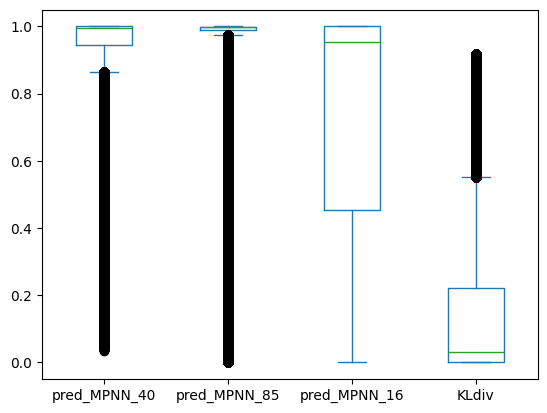

In [6]:
## All data
kldiv_sorted.plot.box()

### Q4 only
Removing outliers, we have high KL divergence, high disagreement between models, and high uncertainty with probabilities nearing the decision boundary (0.5) in some cases


,pred_MPNN_40,pred_MPNN_85,pred_MPNN_16,KLdiv
ID,,,,
5395010_1,0.352946,0.969725,0.030349,0.550204
4955116_1,0.794676,0.879233,0.006163,0.550203
2500902_1,0.851701,0.994661,0.108069,0.550202
3292088_1,0.804864,0.934802,0.034570,0.550202
3477656_1,0.766696,0.979221,0.060391,0.550202
5513167_1,0.938983,0.996576,0.159979,0.550201
2555976_1,0.945613,0.976996,0.137456,0.550201
1195788_1,0.929255,0.990510,0.142752,0.550201
2595506_1,0.884271,0.751669,0.000472,0.550201


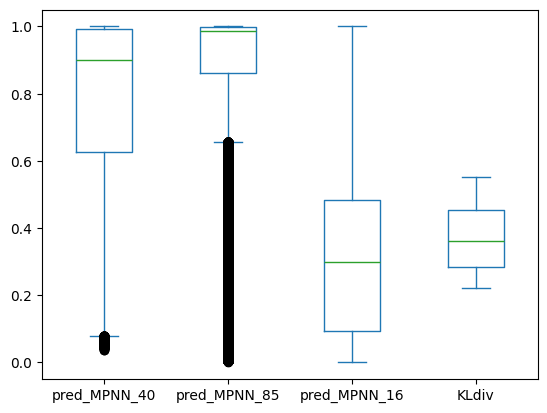

In [7]:
# Q4 Only
q4.plot.box()
q4.head(10)

In [8]:
# Format IDs with fixed id format
ids_uncertain_samples = q4.reset_index()["ID"].map(
    lambda x: f"{x.split('_')[0]}".zfill(
        15) + "_" + f"{x.split('_')[1]}".zfill(5)
)

# Exploration of Model Predictions

(972267,)

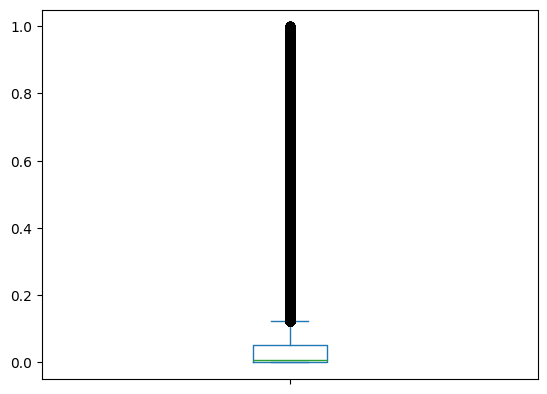

In [41]:
diff = (kldiv_sorted['pred_MPNN_40'] - kldiv_sorted['pred_MPNN_85']).abs().sort_values(ascending=False)
diff.plot.box()
diff[diff > 0.15].shape

(2705165,)

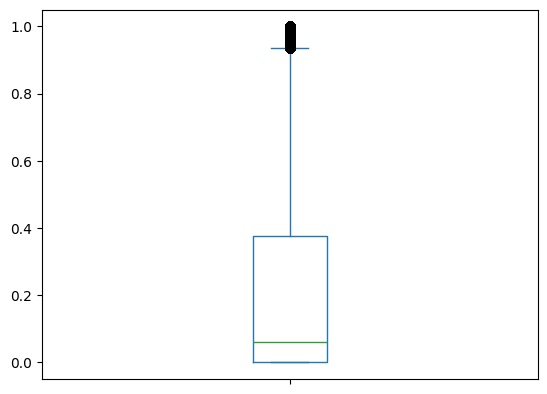

In [42]:
diff = (kldiv_sorted['pred_MPNN_40'] - kldiv_sorted['pred_MPNN_16']).abs().sort_values(ascending=False)
diff.plot.box()
diff[diff > 0.15].shape

(2576496,)

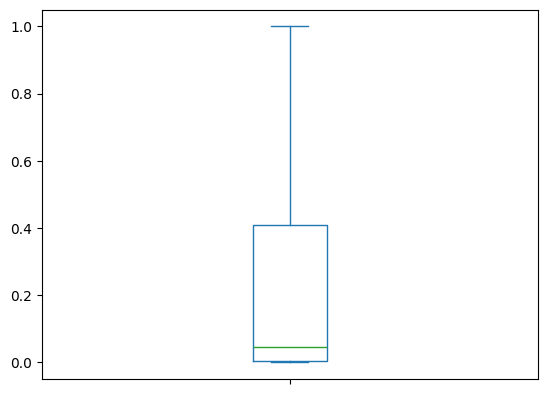

In [43]:
diff = (kldiv_sorted['pred_MPNN_16'] - kldiv_sorted['pred_MPNN_85']).abs().sort_values(ascending=False)
diff.plot.box()
diff[diff > 0.15].shape

# Pure Uncertainty Sampling (unused Sep30th)

In [ ]:
# inference_results_dir = "../inference_results/MPNN_85"

# ######
# # Process inference results
# df = get_inference_results(inference_results_dir)
# display(df.head())


# # Add analysis columns
# df["binary_pred"] = df["pred"].map(lambda x: 1 if x > 0.5 else 0)
# df["entropy"] = df["pred"].map(
#     lambda x: -1
#     * (x * np.log2(x) + (1 - x) * np.log2(1 - x) if x > 0 and x < 1 else 0)
# )

# # Show exploratory analysis
# show_exploratory_analysis(df, save_dir="analysis")

In [3]:
# # select those with entropy == 1
# uncertain_samples: pd.DataFrame = select_most_uncertain(df, save_dir="analysis")

# # Format IDs with fixed id format
# ids_uncertain_samples = uncertain_samples["ID"].map(
#     lambda x: f"{x.split('_')[0]}".zfill(
#         15) + "_" + f"{x.split('_')[1]}".zfill(5)
# )

# ids_uncertain_samples.head()

2024-09-30 07:59:10,538 - INFO - select_most_uncertain:119 - ----------------------------------------------------------------------------------------------------
2024-09-30 07:59:10,538 - INFO - select_most_uncertain:120 - Entropy == 1
2024-09-30 07:59:10,538 - INFO - select_most_uncertain:121 -                 ID      pred  binary_pred  entropy
1358498   315102_1  0.500000            1      1.0
228099   3907926_1  0.500001            1      1.0
742837   5061533_1  0.500002            1      1.0
1191811  6424944_1  0.499997            0      1.0
1574902   419048_1  0.500003            1      1.0
2024-09-30 07:59:10,542 - INFO - select_most_uncertain:122 -              pred  binary_pred       entropy
count  553.000000   553.000000  5.530000e+02
mean     0.500008     0.513562  9.999996e-01
std      0.000350     0.500269  2.964320e-07
min      0.499415     0.000000  9.999990e-01
25%      0.499701     0.000000  9.999994e-01
50%      0.500011     1.000000  9.999997e-01
75%      0.500337    

1358498    000000000315102_00001
228099     000000003907926_00001
742837     000000005061533_00001
1191811    000000006424944_00001
1574902    000000000419048_00001
Name: ID, dtype: object

# Retrieve Target IDs with Descriptors

In [9]:
sampling_space_with_features_dir = "../PolymerDescriptors_Sept2024"
target_samples = get_target_polymers_with_features(
        target_dir=sampling_space_with_features_dir,
        target_ids=ids_uncertain_samples,
    )
assert target_samples.shape[0] == len(ids_uncertain_samples)

## Filter to target descriptors and isolate features

In [14]:
import json
unique_descriptors: list = json.load(open("../unique_descriptors.json", "r"))["node"]
assert isinstance(unique_descriptors, list)
features = target_samples.loc[:, lambda x: x.columns.isin(unique_descriptors)]
print(f'Total columns: {len(features.columns)}')
columns_with_zeros = (features != 0).any(axis=0)[lambda x: x == False]
print(f'Columns with all zeros: {len(columns_with_zeros)}')
features

Total columns: 104
Columns with all zeros: 0


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,MaxPartialCharge,...,RingCount,MolLogP,MolMR,fr_NH0,fr_NH1,fr_NH2,fr_benzene,fr_guanido,fr_para_hydroxylation,fr_unbrch_alkane
360220,18.717840,18.717840,0.001307,-1.788366,0.019858,11023.779,9896.835,11016.447106,4500,0.223069,...,0,34.9506,2989.8078,17,70,0,0,0,0,0
360222,18.527269,18.527269,0.000048,-1.783753,0.019858,10743.016,9672.520,10735.973307,4374,0.223069,...,0,25.6065,2923.0068,17,70,0,0,0,0,0
360223,18.856763,18.856763,0.002177,-1.797619,0.019858,11388.776,10187.240,11381.084589,4662,0.223069,...,0,41.2761,3062.1970,20,70,0,0,0,0,0
360224,18.701000,18.701000,0.000172,-1.795608,0.019858,11228.340,10059.060,11220.813846,4590,0.223069,...,0,36.4989,3028.8570,20,70,0,0,0,0,0
360225,18.932884,18.932884,0.002055,-1.800463,0.019858,11108.013,9962.925,11100.610789,4536,0.223069,...,0,32.9160,3003.8520,20,70,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597706,18.740798,18.740798,0.002574,-1.797707,0.011635,10791.326,9722.846,10784.065147,4380,0.338330,...,24,40.8441,2968.3631,35,49,6,0,3,0,63
597708,18.565947,18.565947,0.002419,-1.775242,0.011635,10284.402,9284.466,10277.535604,4166,0.338330,...,23,29.6787,2808.1654,33,50,6,0,3,0,18
597761,18.798152,18.798152,0.004641,-1.794234,0.011635,11209.810,10105.042,11202.360834,4550,0.338330,...,17,27.3580,3073.1530,23,62,18,0,9,0,63
597787,18.400851,18.400851,0.000003,-1.874021,0.011635,10270.128,9292.368,10263.378938,4152,0.338330,...,19,12.2732,2779.9177,24,59,16,0,8,0,45


## Get Most Diverse Subset

In [15]:
diversity_samples_indices: list[int] = get_diversity_samples(features, N_picks=40)

Picker: MaxMin
Shape: (904368, 104)
Pool size: 904368
Elapsed: 0.11423531373341879
Picks count: 40


In [16]:
diverse_selection = target_samples.reset_index(drop=True).iloc[diversity_samples_indices, :]
target_ids = diverse_selection.ID.map(lambda x: int(x.split("_")[0]))
len(target_ids), target_ids[:5]

(40,
 249717    6841523
 83479     1443590
 434780    1182688
 894260    2637497
 140548    1851986
 Name: ID, dtype: int64)

# Map chosen samples to polymer composition

In [17]:
from pathlib import Path

def get_target_compositions(target_ids: pd.Series, source_compositions_path: str):
    source_compositions_path = Path(source_compositions_path)
    if not source_compositions_path.is_file():
        raise FileNotFoundError("Compositions file doesn't exist.")
    
    df_compositions = pd.read_parquet(source_compositions_path)
    df_compositions["ID"] = df_compositions.ID.str.replace("ID", "").map(lambda x: int(x))
    target_compositions = df_compositions[df_compositions.ID.isin(target_ids)]

    assert len(target_compositions) == len(target_ids)
    assert sorted(target_ids) == sorted(target_compositions.ID.to_list())
    return target_compositions

target_compositions = get_target_compositions(target_ids=target_ids, source_compositions_path="../shoshana_polymers/polymer_combinations.parquet")
target_compositions.head()

,ID,class_distribution,Tma_wt,Aeg_wt,Mo_wt,Mep_wt,Ni_wt,Phe_wt,Do_wt,Bam_wt,Oct_wt,Olam_wt,Bmam_wt,Tmb_wt,monomers,SMILES,mol_distribution
94248,94249,"[10, 60, 30]",10,0,60,0,0,25,0,0,5,0,0,0,"[Tma, Mo, Phe, Oct]","['C[N+](C)(C)CCCNC(=O)C=C', 'C=CC(=O)N1CCOCC1'...","[0.07214548695394302, 0.6338397793404928, 0.25..."
116150,116151,"[10, 45, 45]",10,0,45,0,0,0,15,0,0,30,0,0,"[Tma, Mo, Do, Olam]","['C[N+](C)(C)CCCNC(=O)C=C', 'C=CC(=O)N1CCOCC1'...","[0.09246909453183101, 0.6092958092231817, 0.11..."
246266,246267,"[10, 45, 45]",10,0,0,45,0,10,0,0,5,30,0,0,"[Tma, Mep, Phe, Oct, Olam]","['C[N+](C)(C)CCCNC(=O)C=C', 'C=CC(=O)NCCCOC', ...","[0.08775623412821487, 0.5701243903121583, 0.12..."
518738,518739,"[10, 45, 45]",10,0,15,30,40,5,0,0,0,0,0,0,"[Tma, Mo, Mep, Ni, Phe]","['C[N+](C)(C)CCCNC(=O)C=C', 'C=CC(=O)N1CCOCC1'...","[0.0643640581244384, 0.14136885798933196, 0.27..."
766406,766407,"[45, 15, 40]",45,0,15,0,20,0,0,0,0,5,0,15,"[Tma, Mo, Ni, Olam, Tmb]","['C[N+](C)(C)CCCNC(=O)C=C', 'C=CC(=O)N1CCOCC1'...","[0.3639850079950011, 0.17765658662758066, 0.29..."


In [26]:
df_final = target_compositions.merge(q4.reset_index().assign(ID=lambda x: x.ID.map(lambda y: int(y.split("_")[0]))), on="ID")

columns_order = [
    "ID",
    "monomers",
    "class_distribution",
    "mol_distribution",
    "KLdiv"
]
columns = columns_order + [c for c in df_final.columns if c not in columns_order]
df_final[columns].to_csv("QBC_Sampling_Q4_Only_DiversityPick_40.csv")